# 02 — Behavioural exploratory sweep

The search, labelled as such. Every outcome Gold carries (4 primary, 4 secondary, 4 item pairs, 17 raw items, 11 process, 10 trajectory) × planned \(D\) + format×timing, Friedman (5 and 4-ad), 10 pairwise Wilcoxon, BFI moderation of each \(D\), BFI on person level. Person is the unit throughout.

Three corrections side by side: raw, Holm within `outcome × block`, BH across the whole sweep. **Quote the test count with any p you take from here.** Confirmatory is notebook 01.

Rebuild: `python analysis/walter/behavioural/stats/run_sweep.py`.

In [1]:
from pathlib import Path
import json, sys, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

HERE = Path.cwd().resolve()
while not (HERE / "analysis" / "walter" / "statkit.py").exists():
    HERE = HERE.parent
WALTER = HERE / "analysis" / "walter"
for p in (WALTER, WALTER / "behavioural" / "stats", WALTER / "combos"):
    sys.path.insert(0, str(p))
import statkit as sk
import viz
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 42)
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
GOLD = WALTER / "behavioural" / "outputs" / "gold"
import run_sweep as rs
summary = rs.run()
OUT = rs.OUT
sweep = pd.read_csv(OUT / "sweep_all_tests.csv")
print({k: v for k, v in summary.items() if k not in ("top_bh_hits", "by_tier")})
display(pd.DataFrame(summary["by_tier"]).T)

{'n_tests': 1755, 'n_families': 245, 'hits_raw': 215, 'hits_holm_family': 106, 'hits_bh_global': 53, 'expected_false_raw_at_005': 87.75}


,n_tests,raw,holm_family,bh_global
item_pair,144,42,31,23
primary,144,35,24,15
process,349,11,0,0
raw_item,612,93,31,7
secondary,144,25,12,2
trajectory,362,9,8,6


## 1. How many hits, and how many would noise give

Grey = raw < .05; black tick = 5% of the block's tests (what chance alone gives); orange = Holm within family; red = BH across the sweep. Process and trajectory-by-condition blocks sit at or under chance.

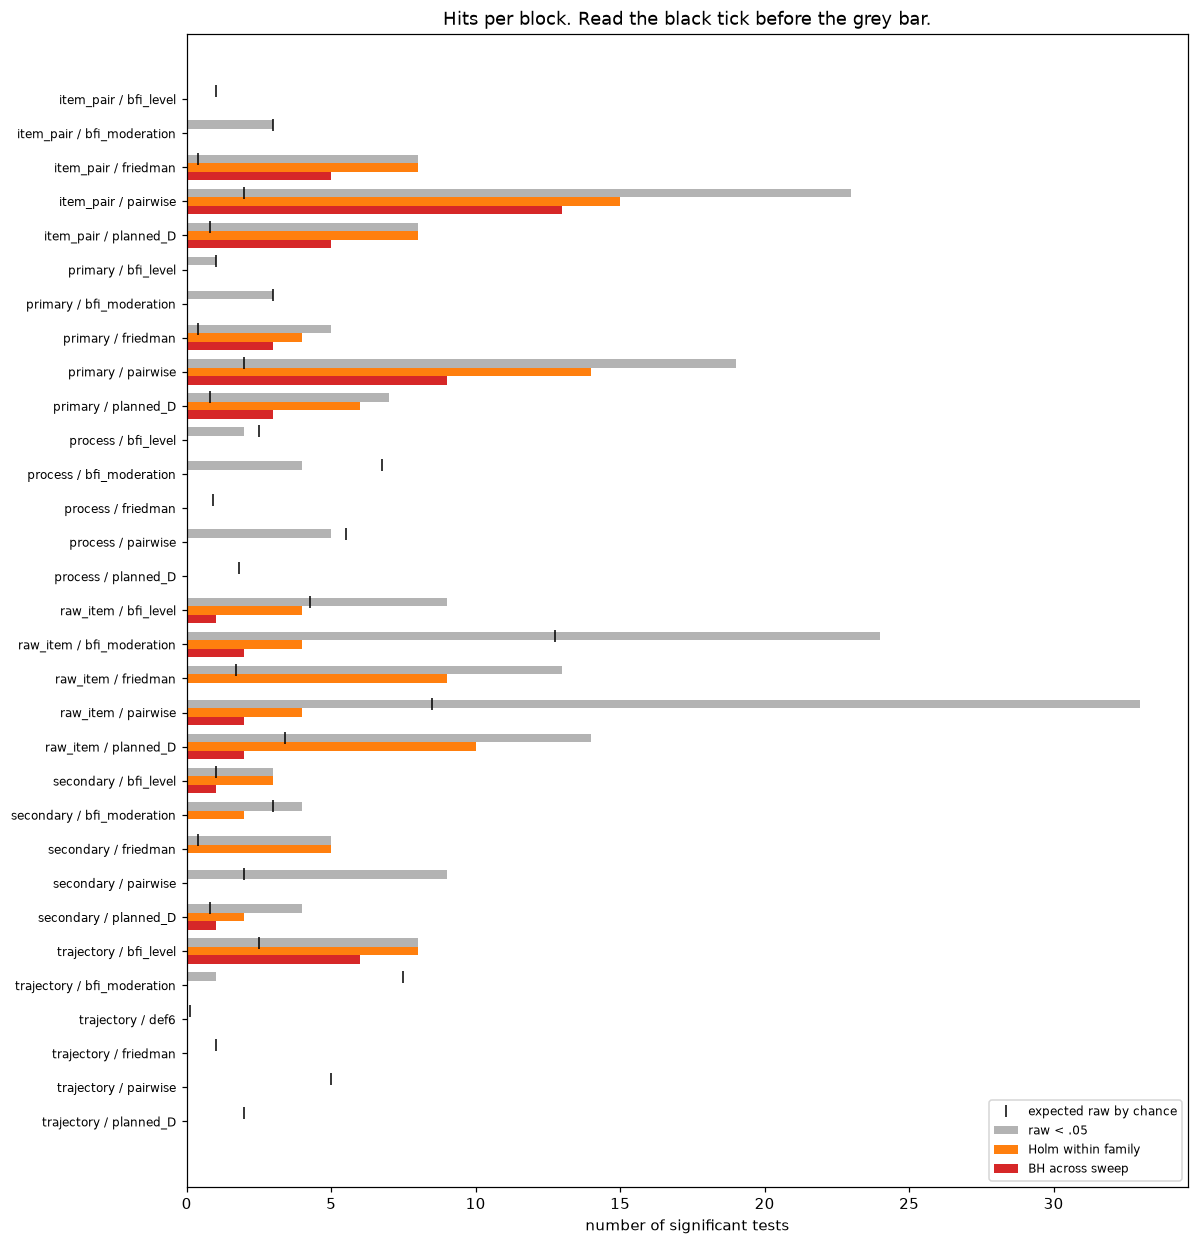

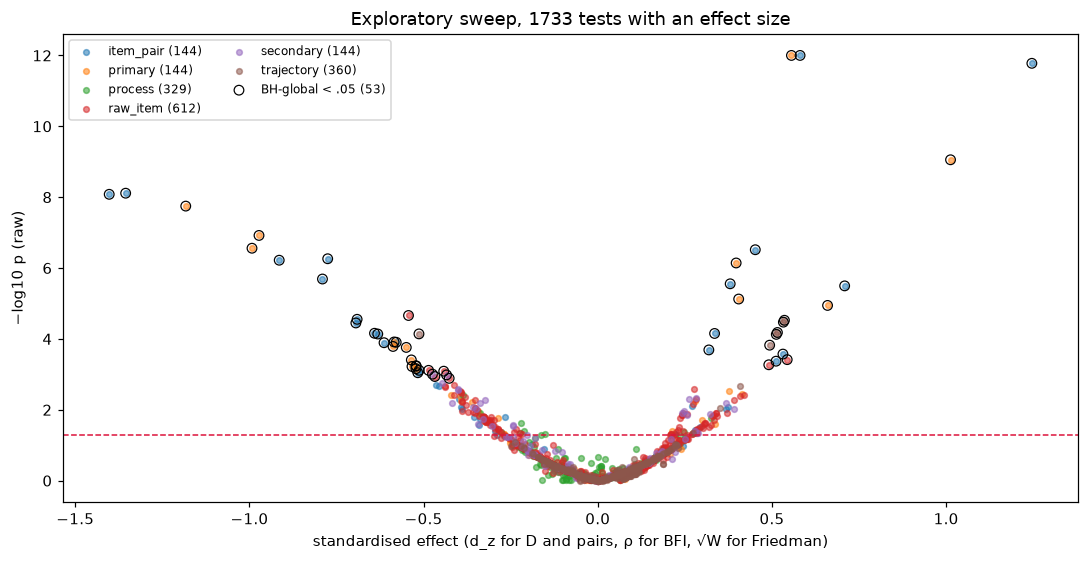

In [2]:
display(viz.hits_by_block(sweep)); plt.close()
display(viz.volcano(sweep)); plt.close()

## 2. The BH survivors (the shopping list)

Sorted by raw p. `n_tests_in_family` and `n_tests_global` are the denominators to report.

In [3]:
hits = pd.read_csv(OUT / "hits_bh_global.csv")
display(hits[["tier", "outcome", "block", "test_label", "n", "effect", "effect_name", "p_raw", "p_holm_family", "p_bh_global", "n_tests_in_family", "n_tests_global"]].round(4))

,tier,outcome,block,test_label,n,effect,effect_name,p_raw,p_holm_family,p_bh_global,n_tests_in_family,n_tests_global
0,item_pair,notice_sponsored,friedman,friedman 5,54,0.3372,Kendall W,0.0000,0.0000,0.0000,2,1755
1,primary,notice,friedman,friedman 5,54,0.3090,Kendall W,0.0000,0.0000,0.0000,2,1755
2,item_pair,notice_sponsored,planned_D,any ad − no ad,54,2.6620,mean D,0.0000,0.0000,0.0000,4,1755
3,primary,notice,planned_D,any ad − no ad,54,2.0741,mean D,0.0000,0.0000,0.0000,4,1755
4,item_pair,notice_sponsored,pairwise,no ad − explicit late,54,-3.4074,mean diff,0.0000,0.0000,0.0000,10,1755
5,item_pair,notice_sponsored,pairwise,no ad − explicit early,54,-3.8148,mean diff,0.0000,0.0000,0.0000,10,1755
6,primary,notice,pairwise,no ad − explicit early,54,-2.8056,mean diff,0.0000,0.0000,0.0000,10,1755
7,primary,manipulation,pairwise,no ad − explicit early,54,-1.9167,mean diff,0.0000,0.0000,0.0000,10,1755
8,primary,notice,pairwise,no ad − explicit late,54,-2.4907,mean diff,0.0000,0.0000,0.0001,10,1755
9,item_pair,notice_sponsored,friedman,friedman 4ad,54,0.2044,Kendall W,0.0000,0.0000,0.0001,2,1755


## 3. The one thing the sweep found that the freeze did not: extraversion × conversational wandering

Person-mean trajectory metrics against BFI-E (\(n=54\)). Level effect, not a treatment effect; it says extraverts wander across genres more and find the bot less relevant.

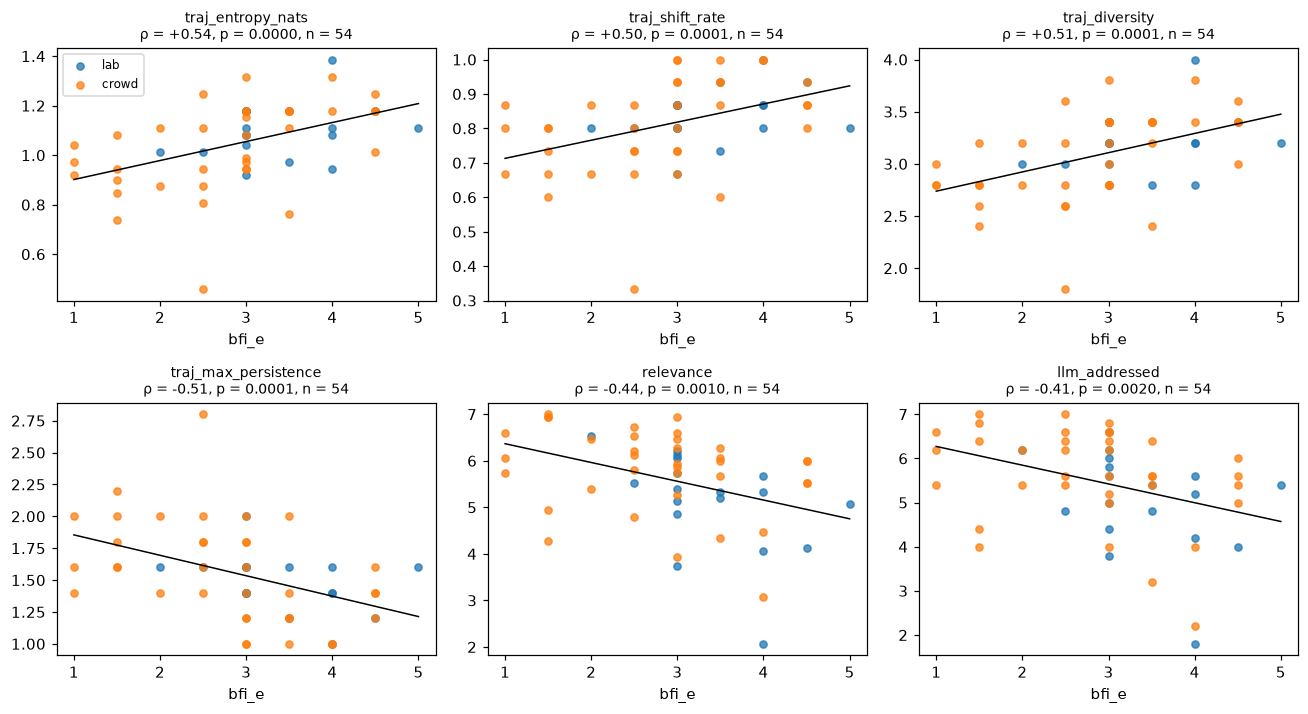

In [4]:
eda = pd.read_csv(WALTER / "behavioural" / "outputs" / "eda" / "person_means.csv") if (WALTER / "behavioural" / "outputs" / "eda" / "person_means.csv").exists() else None
combo = pd.read_csv(GOLD / "combo_threeway.csv")
pm = combo.groupby("experiment_id")[["traj_entropy_nats", "traj_shift_rate", "traj_diversity", "traj_n_shift", "traj_max_persistence", "relevance", "llm_relevant", "llm_addressed", "helpfulness"]].mean()
pm = pm.join(pd.read_csv(GOLD / "person_features.csv").set_index("experiment_id")[["bfi_e", "bfi_a", "bfi_c", "bfi_n", "bfi_o", "arm"]])
display(viz.bfi_scatter_grid(pm, "bfi_e", ["traj_entropy_nats", "traj_shift_rate", "traj_diversity", "traj_max_persistence", "relevance", "llm_addressed"])); plt.close()

## 4. Planned \(D\) and Friedman for every outcome at a glance

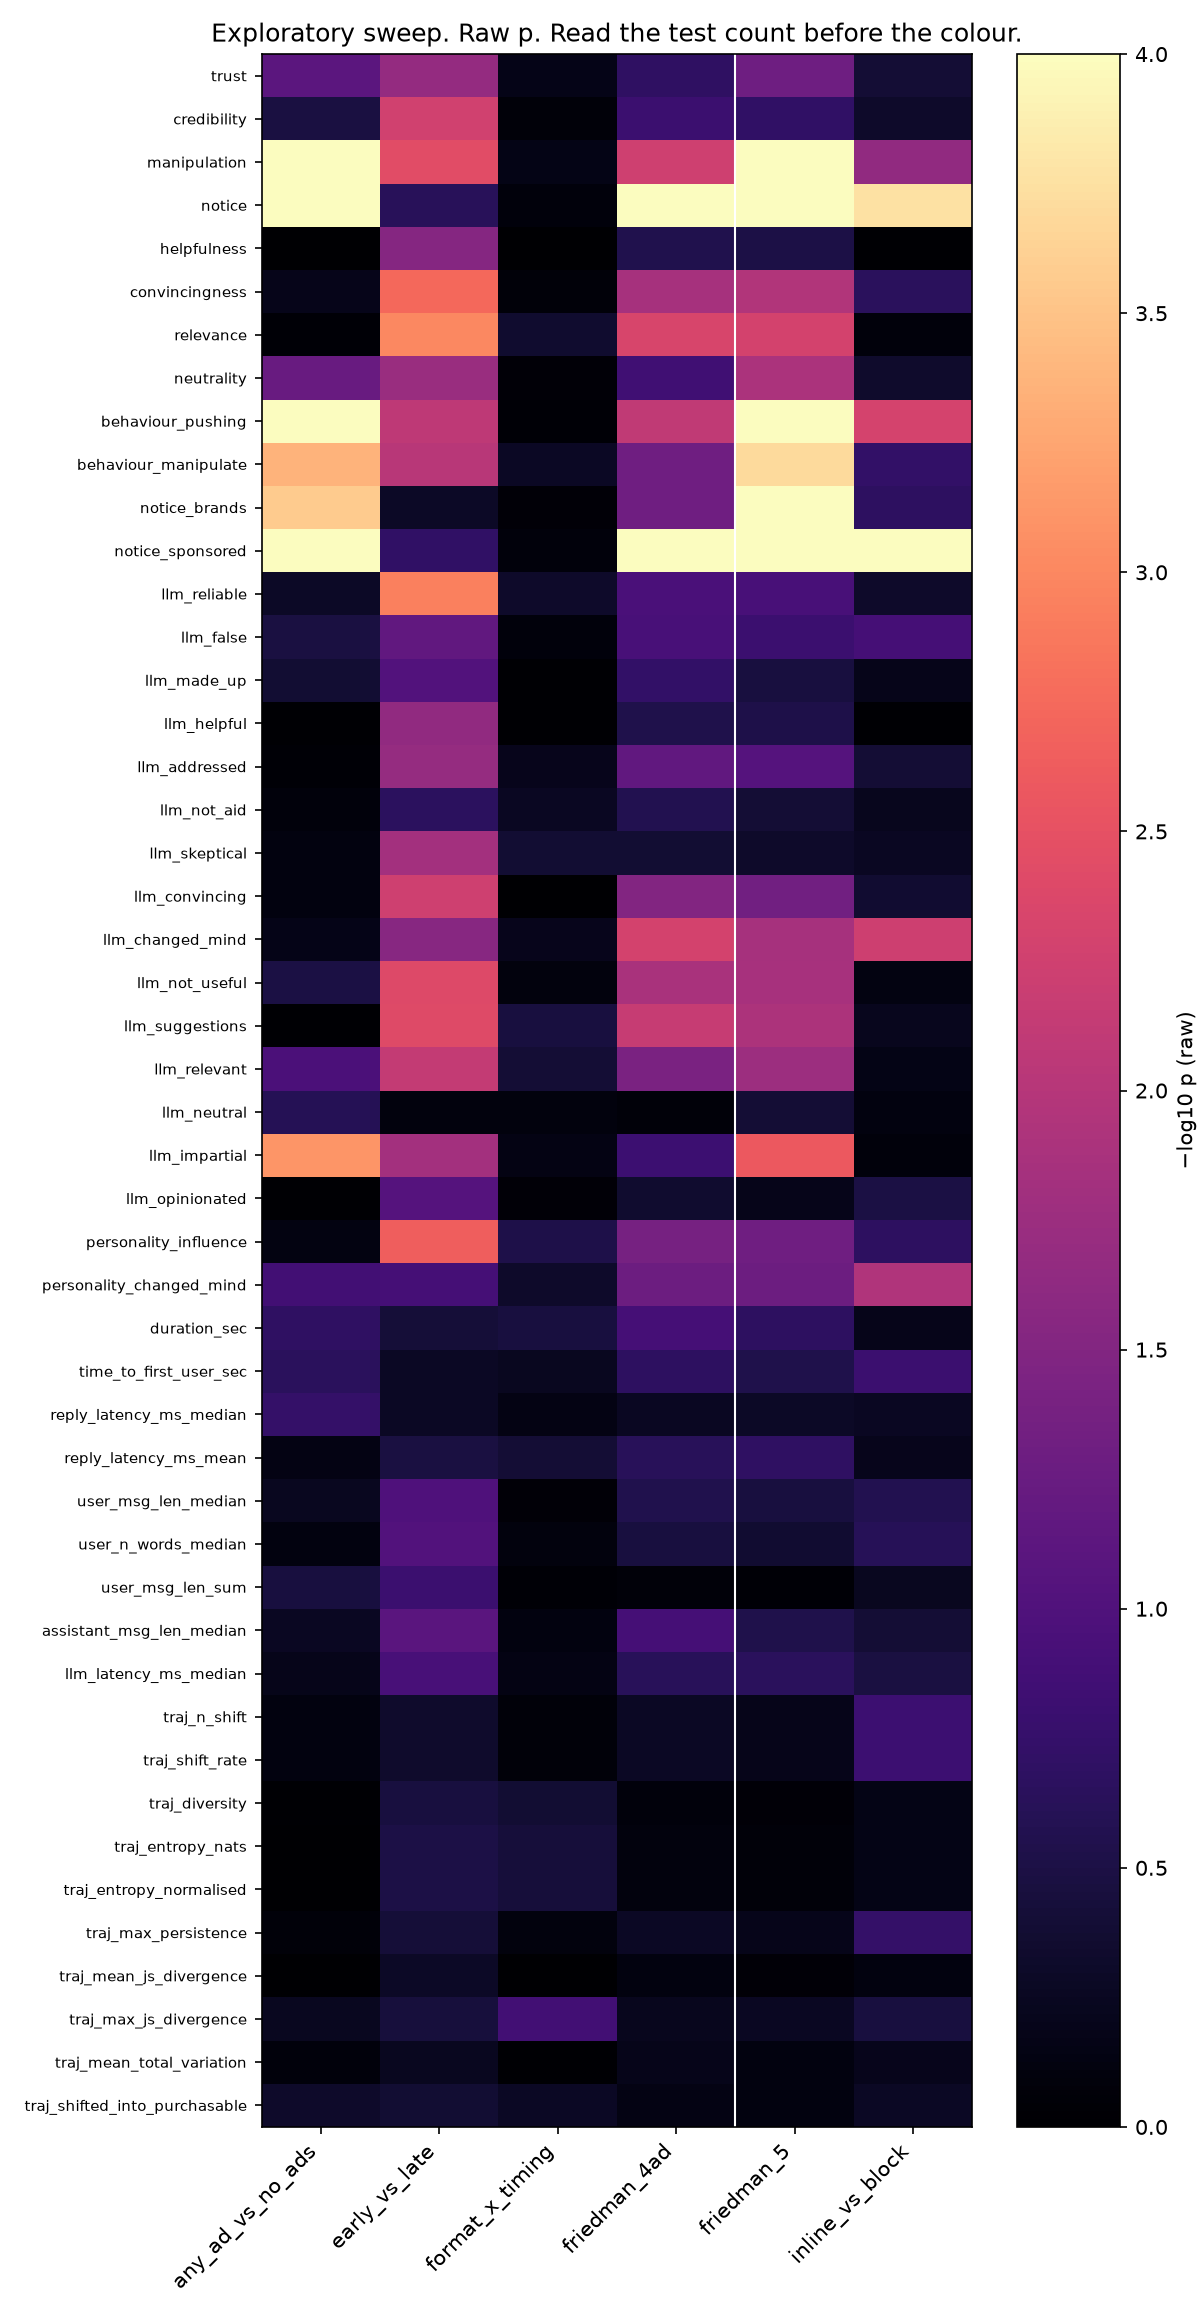

In [5]:
display(Image(OUT / "heat_planned_friedman.png"))

## 5. Pairwise Wilcoxon on the secondary composites and item pairs

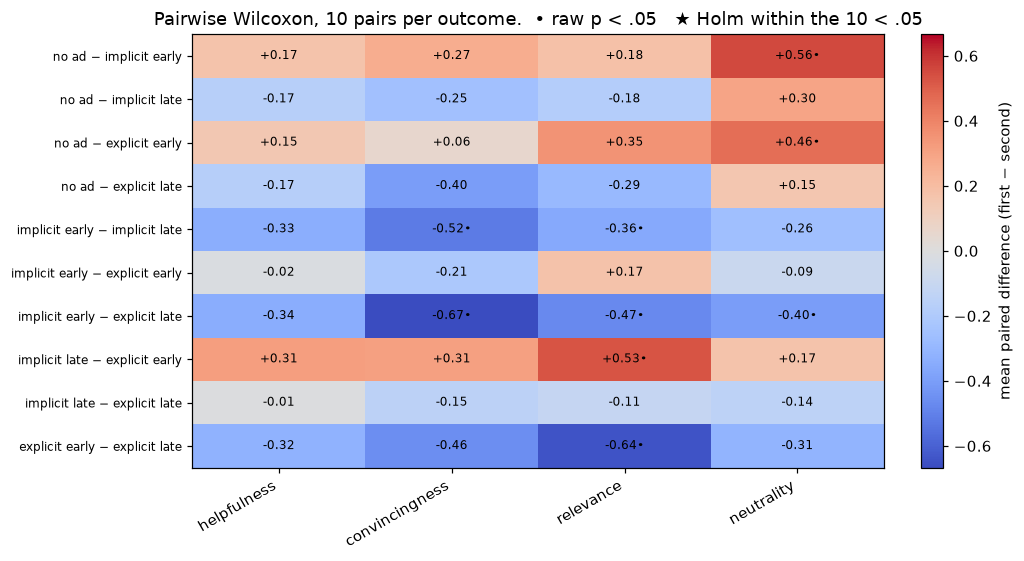

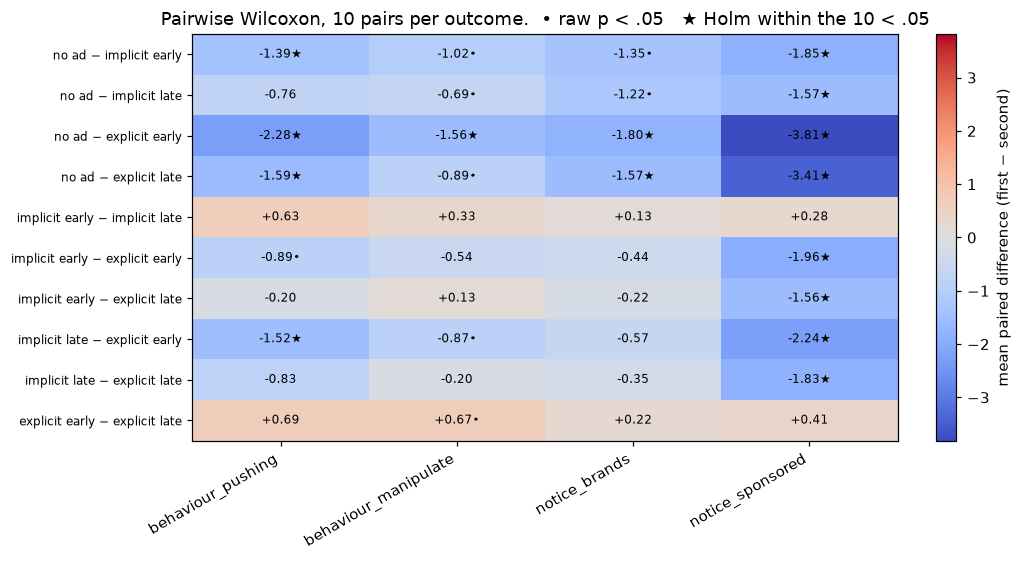

In [6]:
display(viz.pairwise_heat(sweep, ["helpfulness", "convincingness", "relevance", "neutrality"])); plt.close()
display(viz.pairwise_heat(sweep, ["behaviour_pushing", "behaviour_manipulate", "notice_brands", "notice_sponsored"])); plt.close()

## 6. Holm-within-family survivors that BH did not keep, and the full table

In [7]:
h2 = pd.read_csv(OUT / "hits_holm_family.csv"); h2 = h2.loc[~h2["sig_bh_global"]]
display(h2[["tier", "outcome", "block", "test_label", "n", "effect", "p_raw", "p_holm_family", "p_bh_global"]].round(4))
print(sweep.shape); sweep.head(10)

,tier,outcome,block,test_label,n,effect,p_raw,p_holm_family,p_bh_global
53,secondary,convincingness,planned_D,early − late,54,-0.4877,0.0018,0.0072,0.0583
54,item_pair,notice_brands,pairwise,no ad − explicit late,54,-1.5741,0.0020,0.0176,0.0614
55,raw_item,llm_addressed,bfi_level,person mean ~ E,54,-0.4121,0.0020,0.0098,0.0614
56,raw_item,llm_changed_mind,pairwise,implicit early − explicit late,54,-0.9630,0.0021,0.0211,0.0640
57,trajectory,traj_mean_total_variation,bfi_level,person mean ~ E,54,0.4088,0.0021,0.0107,0.0640
58,item_pair,behaviour_pushing,pairwise,no ad − implicit early,54,-1.3889,0.0022,0.0151,0.0640
59,raw_item,personality_influence,planned_D,early − late,54,-0.4907,0.0022,0.0089,0.0653
60,raw_item,llm_impartial,friedman,friedman 5,54,0.0756,0.0026,0.0052,0.0746
61,secondary,relevance,bfi_moderation,early − late ~ E,54,-0.4013,0.0026,0.0396,0.0746
62,secondary,helpfulness,bfi_moderation,early − late ~ E,54,-0.4007,0.0027,0.0402,0.0746


(1755, 27)


,tier,outcome,block,test,test_label,n,effect,effect_name,mean,sd,ci95_lo,ci95_hi,dz,kendall_w,rank_biserial,rho,stat,p_raw,p_wilcoxon,p_holm_family,p_bh_global,sig_raw,sig_holm_family,sig_bh_global,n_tests_in_family,n_tests_global,family
0,item_pair,behaviour_manipulate,bfi_level,level~bfi_e,person mean ~ E,54,0.192527,Spearman rho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.192527,0.192527,0.163088,NaN,0.815439,0.748355,False,False,False,5,1755,behaviour_manipulate|bfi_level
1,item_pair,behaviour_manipulate,bfi_level,level~bfi_o,person mean ~ O,54,-0.093396,Spearman rho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.093396,-0.093396,0.501755,NaN,1.000000,0.963895,False,False,False,5,1755,behaviour_manipulate|bfi_level
2,item_pair,behaviour_manipulate,bfi_level,level~bfi_a,person mean ~ A,54,-0.074862,Spearman rho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.074862,-0.074862,0.590573,NaN,1.000000,0.971779,False,False,False,5,1755,behaviour_manipulate|bfi_level
3,item_pair,behaviour_manipulate,bfi_level,level~bfi_n,person mean ~ N,54,-0.038500,Spearman rho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.038500,-0.038500,0.782243,NaN,1.000000,0.992735,False,False,False,5,1755,behaviour_manipulate|bfi_level
4,item_pair,behaviour_manipulate,bfi_level,level~bfi_c,person mean ~ C,54,-0.013276,Spearman rho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.013276,-0.013276,0.924093,NaN,1.000000,0.999404,False,False,False,5,1755,behaviour_manipulate|bfi_level
5,item_pair,behaviour_manipulate,bfi_moderation,any_ad_vs_no_ads~bfi_o,any ad − no ad ~ O,54,0.210448,Spearman rho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.210448,0.210448,0.126650,NaN,1.000000,0.659557,False,False,False,15,1755,behaviour_manipulate|bfi_moderation
6,item_pair,behaviour_manipulate,bfi_moderation,early_vs_late~bfi_n,early − late ~ N,54,-0.176514,Spearman rho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.176514,-0.176514,0.201669,NaN,1.000000,0.789206,False,False,False,15,1755,behaviour_manipulate|bfi_moderation
7,item_pair,behaviour_manipulate,bfi_moderation,early_vs_late~bfi_o,early − late ~ O,54,-0.126976,Spearman rho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.126976,-0.126976,0.360215,NaN,1.000000,0.917529,False,False,False,15,1755,behaviour_manipulate|bfi_moderation
8,item_pair,behaviour_manipulate,bfi_moderation,inline_vs_block~bfi_c,implicit − explicit ~ C,54,-0.098333,Spearman rho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.098333,-0.098333,0.479313,NaN,1.000000,0.961440,False,False,False,15,1755,behaviour_manipulate|bfi_moderation
9,item_pair,behaviour_manipulate,bfi_moderation,inline_vs_block~bfi_n,implicit − explicit ~ N,54,-0.097440,Spearman rho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.097440,-0.097440,0.483333,NaN,1.000000,0.961440,False,False,False,15,1755,behaviour_manipulate|bfi_moderation
